<a href="https://colab.research.google.com/github/aisssyahF/Cyberbullying_Detection_FYP2/blob/main/FYP1_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **XLM-RoBERTa**

In [ ]:
# Install the transformers library
!pip install transformers

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# Check if Google gave us a GPU
gpu_name = tf.test.gpu_device_name()
if gpu_name:
    print(f"Running on {gpu_name}")
else:
    print("Not running on GPU")

ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
import pandas as pd
import tensorflow as tf
import os

# Define the paths (Trying both 'Root' and 'Content' locations to be safe)
files_to_check = ['train_data.csv', 'validation_data.csv', 'test_data.csv']

def load_file(filename):
    # Option 1: Check Root (Where your screenshot shows they are)
    if os.path.exists('/' + filename):
        return pd.read_csv('/' + filename)
    # Option 2: Check standard Content folder
    elif os.path.exists(filename):
        return pd.read_csv(filename)
    else:
        return None

# 1. Load Data
print("Attempting to find files...")
train_df = load_file('train_data.csv')
val_df = load_file('validation_data.csv')
test_df = load_file('test_data.csv')

# Stop if any file is missing
if train_df is None or val_df is None or test_df is None:
    print("❌ ERROR: Still cannot find the files.")
    print("DEBUG INFO: Your current working directory is:", os.getcwd())
    print("Files in Root:", os.listdir('/'))
else:
    print(f"✅ SUCCESS: Loaded {len(train_df)} training samples.")

    # 2. Tokenizer Setup (Only runs if files are found)
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')
    MAX_LENGTH = 128

    def encode_texts(df):
        return tokenizer(
            df['text'].astype(str).tolist(),
            max_length=MAX_LENGTH,
            padding='max_length',
            truncation=True,
            return_tensors='tf'
        )

    # 3. Tokenize
    print("Tokenizing data...")
    train_encodings = encode_texts(train_df)
    val_encodings = encode_texts(val_df)
    test_encodings = encode_texts(test_df)

    # 4. Create Performance Datasets
    BATCH_SIZE = 32

    train_dataset = tf.data.Dataset.from_tensor_slices((
        dict(train_encodings),
        train_df['label'].values
    )).shuffle(1000).batch(BATCH_SIZE)

    val_dataset = tf.data.Dataset.from_tensor_slices((
        dict(val_encodings),
        val_df['label'].values
    )).batch(BATCH_SIZE)

    # Add the missing test_dataset definition
    test_dataset = tf.data.Dataset.from_tensor_slices(
        dict(test_encodings)
    ).batch(BATCH_SIZE)

    print("✅ Data ready for training!")

Attempting to find files...
✅ SUCCESS: Loaded 21588 training samples.
Tokenizing data...
✅ Data ready for training!


In [ ]:
from transformers import TFAutoModelForSequenceClassification

# 1. Build the Model
# We use 'from_pt=True' to load the PyTorch weights correctly into TensorFlow
model = TFAutoModelForSequenceClassification.from_pretrained(
    'xlm-roberta-base',
    num_labels=2,
    from_pt=True
)

# 2. Compile the Model (Set up the math)
# Learning rate 2e-5 (0.00002) is the "sweet spot" for RoBERTa
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# 3. Start Training
print("🚀 Starting Training on T4 GPU... (This should take about 5-8 minutes)")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

# 4. Save the Model to Colab
save_path = "my_xlm_roberta_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"✅ Training Finished! Model saved to folder: {save_path}")

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFXLMRobertaForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFXLMRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Starting Training on T4 GPU... (This should take about 5-8 minutes)
Epoch 1/3
675/675 [==============================] - 620s 841ms/step - loss: 0.4731 - accuracy: 0.7697 - val_loss: 0.3539 - val_accuracy: 0.8580
Epoch 2/3
675/675 [==============================] - 559s 828ms/step - loss: 0.3368 - accuracy: 0.8599 - val_loss: 0.3430 - val_accuracy: 0.8632
Epoch 3/3
675/675 [==============================] - 558s 827ms/step - loss: 0.2803 - accuracy: 0.8847 - val_loss: 0.3762 - val_accuracy: 0.8558
✅ Training Finished! Model saved to folder: my_xlm_roberta_model


In [ ]:
import numpy as np

print("Making predictions on Test Data:")

# 1. Get raw scores from the model
predictions = model.predict(test_dataset)

# 2. Convert raw scores to final labels (0 or 1)
# argmax finds the highest score (e.g., if Label 1 is 90% and Label 0 is 10%, it picks 1)
y_pred = np.argmax(predictions.logits, axis=1)

# 3. Get the actual answers (Ground Truth)
y_true = test_df['label'].values

print("-Predictions complete-")
print(f"Sample Predictions: {y_pred[:10]}")
print(f"Sample Actuals:     {y_true[:10]}")

Making predictions on Test Data:
85/85 [==============================] - 27s 288ms/step
-Predictions complete-
Sample Predictions: [0 0 1 0 0 0 0 0 0 0]
Sample Actuals:     [1 0 1 0 1 0 1 0 0 0]


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Calculate Accuracy
acc = accuracy_score(y_true, y_pred)

# Generate detailed report
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Hate Speech']))


 Classification Report:

              precision    recall  f1-score   support

      Normal       0.83      0.91      0.87      1472
 Hate Speech       0.88      0.77      0.82      1227

    accuracy                           0.85      2699
   macro avg       0.85      0.84      0.85      2699
weighted avg       0.85      0.85      0.85      2699



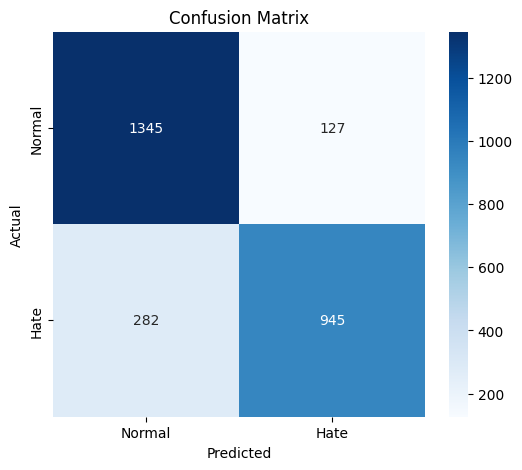

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Graph 1: Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Hate'], yticklabels=['Normal', 'Hate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **XLM-RoBERTa : 5CV (first try is not working)**

In [ ]:
# 1. Install Hugging Face Transformers
!pip install transformers

# 2. Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# 3. Check GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ Success! GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Error: No GPU. Go to Runtime > Change runtime type > T4 GPU")
    device = torch.device("cpu")

✅ Success! GPU Detected: Tesla T4


In [ ]:
!pip install transformers sentencepiece

In [ ]:
# --- Configuration ---
# XLM-R is huge, so we use a small batch size to avoid crashing the GPU RAM
BATCH_SIZE = 16
MAX_LEN = 100
EPOCHS = 3  # Transformers learn very fast. 3 epochs is usually enough.
MODEL_NAME = 'xlm-roberta-base'

# --- 1. Load Data ---
# Make sure you upload these 3 files to the Colab "Files" folder on the left!
train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('validation_data.csv')
test_df = pd.read_csv('test_data.csv')

# Combine Train + Val for 5-Fold CV (The Pool)
X_all = pd.concat([train_df['text'], val_df['text']]).reset_index(drop=True)
y_all = pd.concat([train_df['label'], val_df['label']]).reset_index(drop=True).values

# Prepare Test Data separately
X_test = test_df['text']
y_test = test_df['label'].values

# --- 2. Initialize Tokenizer ---
print("Downloading XLM-RoBERTa Tokenizer...")
tokenizer = XLMRobertaTokenizer.from_pretrained(MODEL_NAME)

# --- 3. Define the Dataset Class ---
# This handles the specific formatting XLM-R needs (Input IDs + Attention Masks)
class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Data & Tokenizer Ready.")

OSError: Unable to load vocabulary from file. Please check that the provided vocabulary is accessible and not corrupted.

In [ ]:
# --- Setup 5-Fold CV ---
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
xmlr_acc = []
xmlr_prec = []
xmlr_rec = []
xmlr_f1 = []

fold_no = 1

print("Starting 5-Fold Cross-Validation for XLM-RoBERTa...")

for train_index, val_index in kfold.split(X_all, y_all):
    print(f"\n" + "="*20)
    print(f"🔹 FOLD {fold_no}/5")
    print("="*20)

    # 1. Split Data
    X_train_fold, X_val_fold = X_all[train_index], X_all[val_index]
    y_train_fold, y_val_fold = y_all[train_index], y_all[val_index]

    # 2. Create Datasets & Loaders
    train_dataset = HateSpeechDataset(X_train_fold.reset_index(drop=True), y_train_fold, tokenizer, MAX_LEN)
    val_dataset = HateSpeechDataset(X_val_fold.reset_index(drop=True), y_val_fold, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    # 3. Load FRESH Model
    model = XLMRobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model = model.to(device)

    # 4. Optimizer
    optimizer = AdamW(model.parameters(), lr=2e-5)

    # 5. Training Loop
    for epoch in range(EPOCHS):
        print(f"  Epoch {epoch+1}/{EPOCHS}...", end="")
        model.train()
        for data in train_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            labels = data['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        print(" Done.")

    # 6. Evaluation Loop
    model.eval()
    y_pred_list = []
    y_true_list = []

    with torch.no_grad():
        for data in val_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            labels = data['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)

            y_pred_list.extend(preds.cpu().numpy())
            y_true_list.extend(labels.cpu().numpy())

    # 7. Calculate & Store Metrics
    acc = accuracy_score(y_true_list, y_pred_list)
    prec = precision_score(y_true_list, y_pred_list, average='macro')
    rec = recall_score(y_true_list, y_pred_list, average='macro')
    f1 = f1_score(y_true_list, y_pred_list, average='macro')

    # --- THIS LINE IS THE FIX ---
    print(f"✅ Result Fold {fold_no} -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    # ----------------------------

    xmlr_acc.append(acc)
    xmlr_prec.append(prec)
    xmlr_rec.append(rec)
    xmlr_f1.append(f1)

    fold_no += 1

# --- Final Average ---
print("\n" + "="*40)
print(f"FINAL 5-FOLD AVERAGE (XLM-RoBERTa):")
print(f"Accuracy:  {np.mean(xmlr_acc)*100:.2f}%")
print(f"Precision: {np.mean(xmlr_prec)*100:.2f}%")
print(f"Recall:    {np.mean(xmlr_rec)*100:.2f}%")
print(f"F1-Score:  {np.mean(xmlr_f1)*100:.2f}%")
print("="*40)

Starting 5-Fold Cross-Validation for XLM-RoBERTa...

🔹 FOLD 1/5


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3...

AttributeError: XLMRobertaTokenizer has no attribute encode_plus

# **XLM-RoBERTa : 5CV REAL**


In [ ]:
# 1. Install necessary libraries
!pip install transformers sentencepiece

# 2. Imports (PyTorch Version)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from torch.optim import AdamW # Corrected import: AdamW is imported from torch.optim
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import os

# 3. Check GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ Success! GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Error: No GPU. Go to Runtime > Change runtime type > T4 GPU")
    device = torch.device("cpu")

✅ Success! GPU Detected: Tesla T4


In [ ]:
# --- Configuration ---
BATCH_SIZE = 16
MAX_LEN = 100
EPOCHS = 3
MODEL_NAME = 'xlm-roberta-base'

# 1. Load Data
try:
    train_df = pd.read_csv('train_data.csv')
    val_df = pd.read_csv('validation_data.csv')
    test_df = pd.read_csv('test_data.csv')
    print("Files loaded successfully.")
except FileNotFoundError:
    print("❌ ERROR: Please upload train_data.csv, validation_data.csv, and test_data.csv to Colab!")

# 2. Combine Data for 5-Fold CV
X_all = pd.concat([train_df['text'], val_df['text']]).reset_index(drop=True)
y_all = pd.concat([train_df['label'], val_df['label']]).reset_index(drop=True).values

# 3. Initialize Tokenizer
print("Downloading Tokenizer...")
# We use use_fast=False to avoid some specific Colab bugs
tokenizer = XLMRobertaTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print("Tokenizer Ready.")

Files loaded successfully.


HTTP Error 500 thrown while requesting HEAD https://huggingface.co/xlm-roberta-base/resolve/main/sentencepiece.bpe.model
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting HEAD https://huggingface.co/xlm-roberta-base/resolve/main/sentencepiece.bpe.model
Retrying in 2s [Retry 2/5].


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/xlm-roberta-base/resolve/main/sentencepiece.bpe.model: The read operation timed out
Trying to resume download...
Trying to resume download...


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizer Ready.


In [ ]:
class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # ✅ FIXED CODE: Calling tokenizer directly
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("✅ Dataset Class Defined (Fixed Version).")

✅ Dataset Class Defined (Fixed Version).


In [ ]:
# --- Setup 5-Fold CV ---
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
xmlr_acc = []
xmlr_prec = []
xmlr_rec = []
xmlr_f1 = []

fold_no = 1

print("Starting 5-Fold Cross-Validation for XLM-RoBERTa...")

for train_index, val_index in kfold.split(X_all, y_all):
    print(f"\n" + "="*20)
    print(f"🔹 FOLD {fold_no}/5")
    print("="*20)

    # 1. Split Data
    X_train_fold, X_val_fold = X_all[train_index], X_all[val_index]
    y_train_fold, y_val_fold = y_all[train_index], y_all[val_index]

    # 2. Create Datasets & Loaders
    train_dataset = HateSpeechDataset(X_train_fold.reset_index(drop=True), y_train_fold, tokenizer, MAX_LEN)
    val_dataset = HateSpeechDataset(X_val_fold.reset_index(drop=True), y_val_fold, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    # 3. Load FRESH Model
    model = XLMRobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model = model.to(device)

    # 4. Optimizer
    optimizer = AdamW(model.parameters(), lr=2e-5)

    # 5. Training Loop
    for epoch in range(EPOCHS):
        print(f"  Epoch {epoch+1}/{EPOCHS}...", end="")
        model.train()
        for data in train_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            labels = data['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        print(" Done.")

    # 6. Evaluation Loop
    model.eval()
    y_pred_list = []
    y_true_list = []

    with torch.no_grad():
        for data in val_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            labels = data['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)

            y_pred_list.extend(preds.cpu().numpy())
            y_true_list.extend(labels.cpu().numpy())

    # 7. Calculate & Store Metrics
    acc = accuracy_score(y_true_list, y_pred_list)
    prec = precision_score(y_true_list, y_pred_list, average='macro')
    rec = recall_score(y_true_list, y_pred_list, average='macro')
    f1 = f1_score(y_true_list, y_pred_list, average='macro')

    print(f"✅ Result Fold {fold_no} -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    xmlr_acc.append(acc)
    xmlr_prec.append(prec)
    xmlr_rec.append(rec)
    xmlr_f1.append(f1)

    fold_no += 1

# --- Final Average ---
print("\n" + "="*40)
print(f"FINAL 5-FOLD AVERAGE (XLM-RoBERTa):")
print(f"Accuracy:  {np.mean(xmlr_acc)*100:.2f}%")
print(f"Precision: {np.mean(xmlr_prec)*100:.2f}%")
print(f"Recall:    {np.mean(xmlr_rec)*100:.2f}%")
print(f"F1-Score:  {np.mean(xmlr_f1)*100:.2f}%")
print("="*40)

Starting 5-Fold Cross-Validation for XLM-RoBERTa...

🔹 FOLD 1/5


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3... Done.
  Epoch 2/3... Done.
  Epoch 3/3... Done.
✅ Result Fold 4 -> Acc: 0.8565 | Prec: 0.8555 | Rec: 0.8576 | F1: 0.8560

🔹 FOLD 5/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3... Done.
  Epoch 2/3... Done.
  Epoch 3/3... Done.
✅ Result Fold 5 -> Acc: 0.8575 | Prec: 0.8563 | Rec: 0.8579 | F1: 0.8569

FINAL 5-FOLD AVERAGE (XLM-RoBERTa):
Accuracy:  85.49%
Precision: 85.44%
Recall:    85.63%
F1-Score:  85.44%
